# Test: ParticleSpringForceDynamicField generator

Visualize 3D particles with spring forces + chemotaxis from a moving Gaussian field.

Three panels per frame:
1. 3D scatter of particle positions
2. Top-down (xy) projection of particles
3. Top-down projection of the chemical field with particles overlaid

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from pathlib import Path
from tqdm import trange
from IPython.display import Video, display
import matplotlib.animation as animation

from cell_gnn.cell_state import CellState
from cell_gnn.utils import edges_radius_blockwise, choose_boundary_values
from cell_gnn.generators.particle_spring_force_dynamic_field import (
    ParticleSpringForceDynamicField,
    moving_gaussian_field,
)
from cell_gnn.integrators import rk4_step

## Parameters

In [20]:
device = 'cpu'

# simulation
n_cells = 1000
dimension = 3
n_frames = 2000
delta_t = 0.002
max_radius = 0.15
min_radius = 0.0
noise_level = 0.01

# spring force params: [k_rep, r0, kadh, r_on, delta, mu_f]
cell_params = torch.tensor([50.0, 0.1, 50.0, 0.14, 0.001, 0.033], device=device)

# dynamic field params
field_params = {
    'center_0': torch.tensor([0.2, 0.5, 0.5], device=device),
    'velocity': torch.tensor([0.15, 0.0, 0.0], device=device),  # moves in x
    'amplitude': 1.0,
    'sigma': 0.15,
    'mu_chem': 0.5,
    'delta_t': delta_t,
    'periodic': True,
}

# boundary conditions
bc_pos, bc_dpos = choose_boundary_values('periodic')

## Initialize cells & model

In [21]:
torch.manual_seed(42)

# random initial positions in [0,1]^3
pos = torch.rand(n_cells, dimension, device=device)
vel = torch.zeros(n_cells, dimension, device=device)

x = CellState(
    index=torch.arange(n_cells, device=device),
    pos=pos,
    vel=vel,
    cell_type=torch.zeros(n_cells, dtype=torch.long, device=device),
    field=torch.ones(n_cells, 1, device=device),
)

model = ParticleSpringForceDynamicField(
    aggr_type='add',
    p=cell_params,
    bc_dpos=bc_dpos,
    dimension=dimension,
    noise_model_level=noise_level,
    field_params=field_params,
)

print(f'Cells: {n_cells}, Frames: {n_frames}, dt: {delta_t}')

Cells: 1000, Frames: 2000, dt: 0.002


## Run simulation

In [22]:
# store snapshots for video
save_every = 10
pos_history = []
field_history = []
time_history = []

for it in trange(n_frames, ncols=100, desc='simulating'):
    # save snapshot
    if it % save_every == 0:
        t = it * delta_t
        C, grad_C = moving_gaussian_field(x.pos, t, field_params)
        pos_history.append(x.pos.clone().detach().numpy())
        field_history.append(C.clone().detach().squeeze().numpy())
        time_history.append(t)

    # RK4 step
    def _deriv_fn(s, _it=it):
        ei = edges_radius_blockwise(s.pos, bc_dpos, min_radius, max_radius, block=2048)
        return model(s, ei, k=_it)

    x, _ = rk4_step(x, _deriv_fn, delta_t, 'first_derivative', bc_pos)

print(f'Saved {len(pos_history)} snapshots')

simulating: 100%|███████████████████████████████████████████████| 2000/2000 [01:26<00:00, 23.23it/s]

Saved 200 snapshots


## Generate video

In [23]:
pos_history = np.array(pos_history)
field_history = np.array(field_history)
time_history = np.array(time_history)

n_snapshots = len(time_history)
print(f'{n_snapshots} frames, time range [{time_history[0]:.3f}, {time_history[-1]:.3f}]')

200 frames, time range [0.000, 3.980]


In [24]:
# field grid for top-down field plot
grid_res = 100
gx = np.linspace(0, 1, grid_res)
gy = np.linspace(0, 1, grid_res)
GX, GY = np.meshgrid(gx, gy)
grid_xy = np.stack([GX.ravel(), GY.ravel()], axis=1)  # (grid_res^2, 2)


def compute_field_image(t):
    """Compute top-down (xy) field by evaluating at z=0.5 and returning 2D image."""
    grid_3d = np.zeros((grid_res * grid_res, 3))
    grid_3d[:, 0] = grid_xy[:, 0]
    grid_3d[:, 1] = grid_xy[:, 1]
    grid_3d[:, 2] = 0.5  # mid-plane
    grid_t = torch.tensor(grid_3d, dtype=torch.float32)
    C, _ = moving_gaussian_field(grid_t, t, field_params)
    return C.squeeze().numpy().reshape(grid_res, grid_res)


# test
img0 = compute_field_image(0.0)
print(f'Field image shape: {img0.shape}, range: [{img0.min():.3f}, {img0.max():.3f}]')

Field image shape: (100, 100), range: [0.000, 0.999]


In [25]:
out_dir = Path('../tmp_training/dynamic_field_test')
out_dir.mkdir(parents=True, exist_ok=True)

fig = plt.figure(figsize=(18, 6))

# panel 1: 3D scatter
ax1 = fig.add_subplot(131, projection='3d')
# panel 2: top-down particles
ax2 = fig.add_subplot(132)
# panel 3: top-down field + particles
ax3 = fig.add_subplot(133)

vmax_field = field_params['amplitude']


def update(frame_idx):
    pos = pos_history[frame_idx]
    t = time_history[frame_idx]
    fvals = field_history[frame_idx]

    # --- Panel 1: 3D ---
    ax1.cla()
    ax1.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=3, c=fvals, cmap='YlOrRd',
               vmin=0, vmax=vmax_field, alpha=0.7)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_zlim(0, 1)
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.set_zlabel('z')
    ax1.set_title(f'3D  t={t:.3f}')

    # --- Panel 2: top-down xy ---
    ax2.cla()
    ax2.scatter(pos[:, 0], pos[:, 1], s=3, c=fvals, cmap='YlOrRd',
               vmin=0, vmax=vmax_field, alpha=0.7)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.set_aspect('equal')
    ax2.set_xlabel('x')
    ax2.set_ylabel('y')
    ax2.set_title('Top-down particles')

    # --- Panel 3: field + particles ---
    ax3.cla()
    field_img = compute_field_image(t)
    ax3.imshow(field_img, extent=[0, 1, 0, 1], origin='lower',
               cmap='Blues', vmin=0, vmax=vmax_field, alpha=0.8)
    ax3.scatter(pos[:, 0], pos[:, 1], s=3, c='red', alpha=0.5)
    ax3.set_xlim(0, 1)
    ax3.set_ylim(0, 1)
    ax3.set_aspect('equal')
    ax3.set_xlabel('x')
    ax3.set_ylabel('y')
    ax3.set_title('Field + particles')

    fig.suptitle(f'Frame {frame_idx}/{n_snapshots}  t={t:.3f}', fontsize=14)
    fig.tight_layout()


print('Rendering video...')
ani = animation.FuncAnimation(fig, update, frames=n_snapshots, interval=50)
video_path = str(out_dir / 'dynamic_field_test.mp4')
ani.save(video_path, writer='ffmpeg', fps=30, dpi=100)
plt.close(fig)
print(f'Saved: {video_path}')

Rendering video...
Saved: ../tmp_training/dynamic_field_test/dynamic_field_test.mp4


In [26]:
display(Video(video_path, embed=True, width=900))

## Static snapshots (first, middle, last)

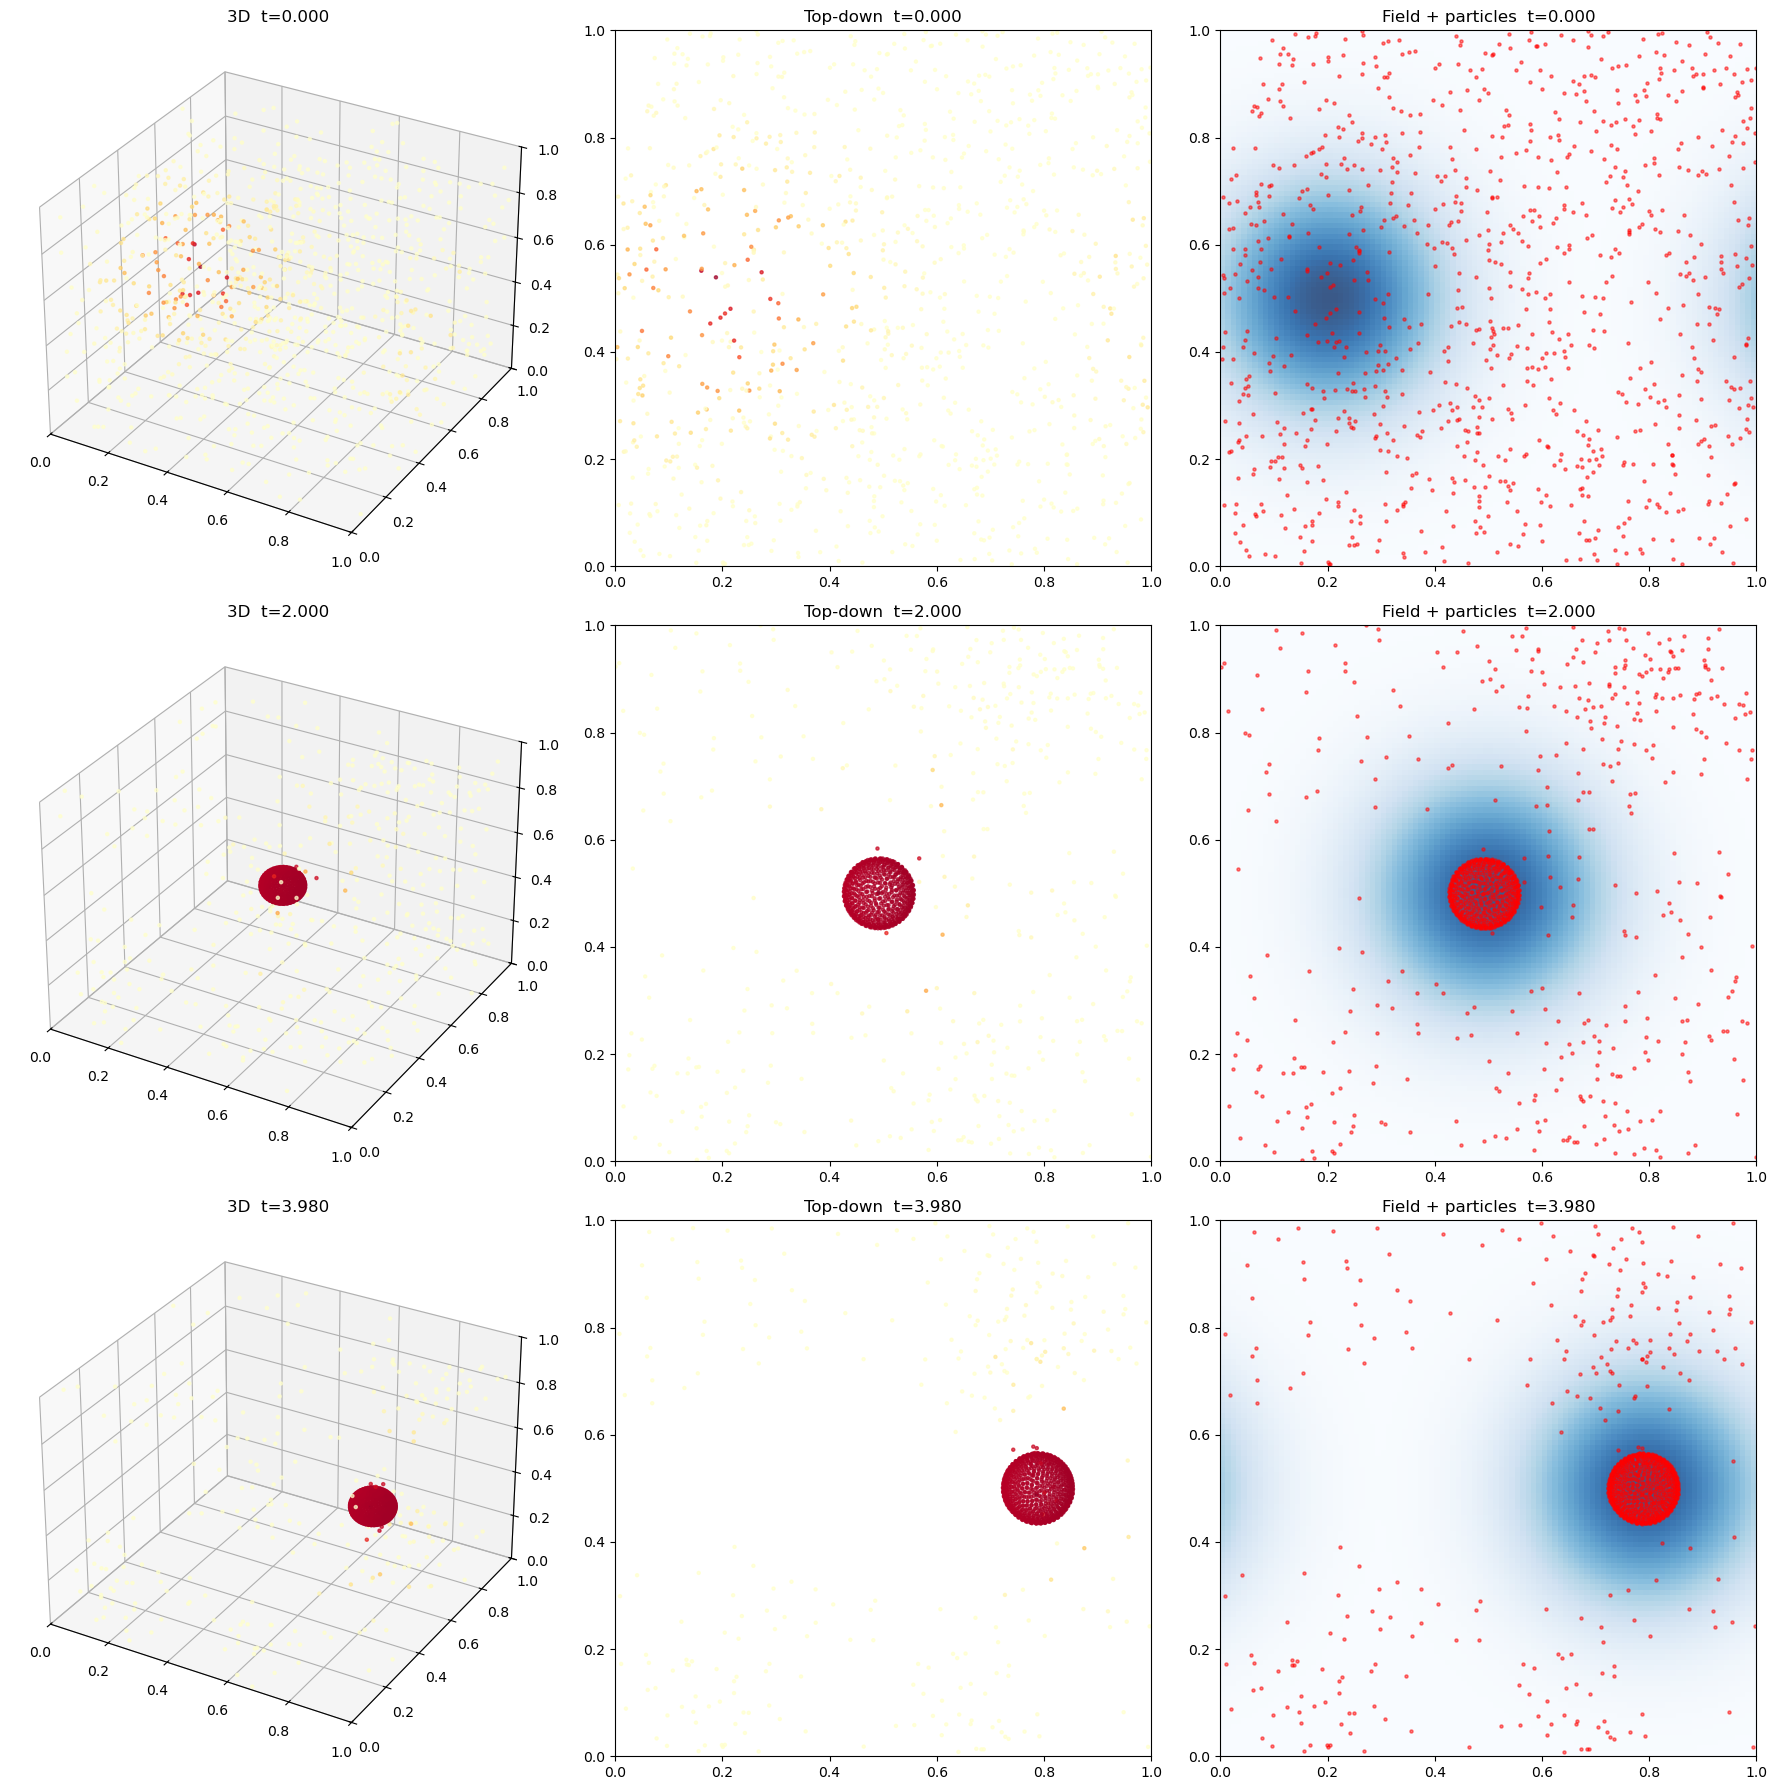

Saved snapshots to ../tmp_training/dynamic_field_test/snapshots.png


In [27]:
snap_indices = [0, n_snapshots // 2, n_snapshots - 1]

fig, axes = plt.subplots(len(snap_indices), 3, figsize=(18, 6 * len(snap_indices)))

for row, idx in enumerate(snap_indices):
    pos = pos_history[idx]
    t = time_history[idx]
    fvals = field_history[idx]
    field_img = compute_field_image(t)

    # 3D
    ax = fig.add_subplot(len(snap_indices), 3, row * 3 + 1, projection='3d')
    ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=5, c=fvals, cmap='YlOrRd',
              vmin=0, vmax=vmax_field, alpha=0.7)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_zlim(0, 1)
    ax.set_title(f'3D  t={t:.3f}')

    # top-down particles
    ax2 = axes[row, 1]
    ax2.scatter(pos[:, 0], pos[:, 1], s=5, c=fvals, cmap='YlOrRd',
               vmin=0, vmax=vmax_field, alpha=0.7)
    ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.set_aspect('equal')
    ax2.set_title(f'Top-down  t={t:.3f}')

    # field + particles
    ax3 = axes[row, 2]
    ax3.imshow(field_img, extent=[0, 1, 0, 1], origin='lower',
              cmap='Blues', vmin=0, vmax=vmax_field, alpha=0.8)
    ax3.scatter(pos[:, 0], pos[:, 1], s=5, c='red', alpha=0.5)
    ax3.set_xlim(0, 1); ax3.set_ylim(0, 1); ax3.set_aspect('equal')
    ax3.set_title(f'Field + particles  t={t:.3f}')

    # hide the axes[row, 0] since we replaced it with 3D projection
    axes[row, 0].set_visible(False)

fig.tight_layout()
fig.savefig(str(out_dir / 'snapshots.png'), dpi=150)
plt.show()
print(f'Saved snapshots to {out_dir / "snapshots.png"}')